# Feature Engineering -- Theory in Code, with scikit-learn
### Concepts Track -- Lecture 05

Companion notebook to the Feature Engineering slides. The goal here isn't a long list of function
calls -- it's a **mental model** for each technique: what problem it solves, how to tell when you
need it, and what it looks like to get it wrong. Every idea gets a before/after picture, not just a
formula.

**session structure:**
1. Missing values -- imputation strategies, and when "missing" is itself useful information
2. Scaling and skew -- which models care, and fixing lopsided distributions
3. Binning -- turning a number into a category, and what that trades away
4. Categorical encoding -- one-hot, ordinal, and target encoding for high-cardinality columns
5. Date and time features -- extracting signal, and the cyclical-encoding trap
6. Interaction features -- when two columns together say more than either alone
7. Aggregation features -- comparing a row to its group
8. The leakage trap for feature engineering -- a concrete, numeric demonstration
9. Outliers -- detecting them, and deciding what to do
10. Putting it all together in one honest pipeline

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, OrdinalEncoder,
                                    PowerTransformer, KBinsDiscretizer, PolynomialFeatures)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
print('NumPy:', np.__version__, '| Pandas:', pd.__version__)

NumPy: 2.4.6 | Pandas: 3.0.5


---
## Part 1 -- Missing Values: Filling Gaps Thoughtfully

**The mental model:** a model can't work with a blank cell -- something has to go there. The
question is never "should I fill it in," it's "what should I fill it in with, and does the fact
that it was missing in the first place matter too?"

In [2]:
# A small, realistic slice of data with missing values in two different columns.
data = pd.DataFrame({
    'age': [25, 42, np.nan, 31, 55, np.nan, 38, 29],
    'income': [40000, 85000, 62000, np.nan, 120000, 55000, np.nan, 47000],
})
print(data)
print(f'\nMissing per column:\n{data.isna().sum()}')

    age    income
0  25.0   40000.0
1  42.0   85000.0
2   NaN   62000.0
3  31.0       NaN
4  55.0  120000.0
5   NaN   55000.0
6  38.0       NaN
7  29.0   47000.0

Missing per column:
age       2
income    2
dtype: int64


### 1.1 -- Comparing Imputation Strategies Side by Side

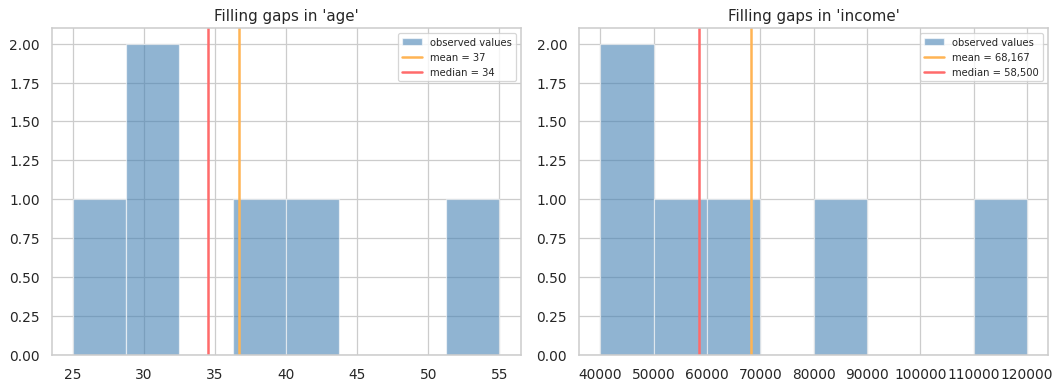

In [3]:
strategies = ['mean', 'median']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col in zip(axes, ['age', 'income']):
    original = data[col].dropna()
    ax.hist(original, bins=8, color='steelblue', alpha=0.6, label='observed values')
    for strategy, color in zip(strategies, ['#ffb454', '#ff6b6b']):
        fill_value = original.mean() if strategy == 'mean' else original.median()
        ax.axvline(fill_value, color=color, linewidth=2, label=f'{strategy} = {fill_value:,.0f}')
    ax.set_title(f"Filling gaps in '{col}'")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Why the choice matters:** mean and median agree closely when a column is roughly symmetric (like
`age` here). They can diverge a lot on a skewed column (like `income`, where a few very high
earners drag the mean upward) -- and imputing with a mean that's been pulled away from where most
of the data actually sits quietly injects a small bias into every row that gets filled.

In [3]:
# SimpleImputer does this at scale, and remembers the fitted fill value for use on new data later --
# exactly like a scaler or encoder, it has to be FIT on training data only (Lecture 04's rule).
imputer = SimpleImputer(strategy='median')
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)
print(data_imputed)
print(f"\nLearned fill values: {dict(zip(data.columns, imputer.statistics_))}")

    age    income
0  25.0   40000.0
1  42.0   85000.0
2  34.5   62000.0
3  31.0   58500.0
4  55.0  120000.0
5  34.5   55000.0
6  38.0   58500.0
7  29.0   47000.0

Learned fill values: {'age': np.float64(34.5), 'income': np.float64(58500.0)}


### 1.2 -- When 'Missing' Itself Is Useful Information

In [4]:
# add_indicator=True keeps BOTH the filled value and a new 0/1 column marking where data was
# originally missing -- the model can use either signal, or both.
imputer_with_flag = SimpleImputer(strategy='median', add_indicator=True)
result = imputer_with_flag.fit_transform(data)
result_df = pd.DataFrame(result, columns=['age', 'income', 'age_was_missing', 'income_was_missing'])
print(result_df)

    age    income  age_was_missing  income_was_missing
0  25.0   40000.0              0.0                 0.0
1  42.0   85000.0              0.0                 0.0
2  34.5   62000.0              1.0                 0.0
3  31.0   58500.0              0.0                 1.0
4  55.0  120000.0              0.0                 0.0
5  34.5   55000.0              1.0                 0.0
6  38.0   58500.0              0.0                 1.0
7  29.0   47000.0              0.0                 0.0


**The mental model for this flag:** imagine a loan application where `income` is missing because
the applicant chose not to disclose it -- that choice might itself correlate with risk, completely
separately from whatever income value eventually gets filled in. Without the flag, that signal is
gone the moment the gap is filled. With it, the model gets to decide for itself whether "was this
missing" mattered.

---
## Part 2 -- Scaling and Skew

**The mental model:** some models compare features directly to each other (distance, gradient
steps) -- for those, a feature measured in the thousands can quietly dominate one measured in
single digits, for no reason related to actual importance. Other models (trees) split one feature
at a time and never make that comparison, so scale doesn't affect them at all.

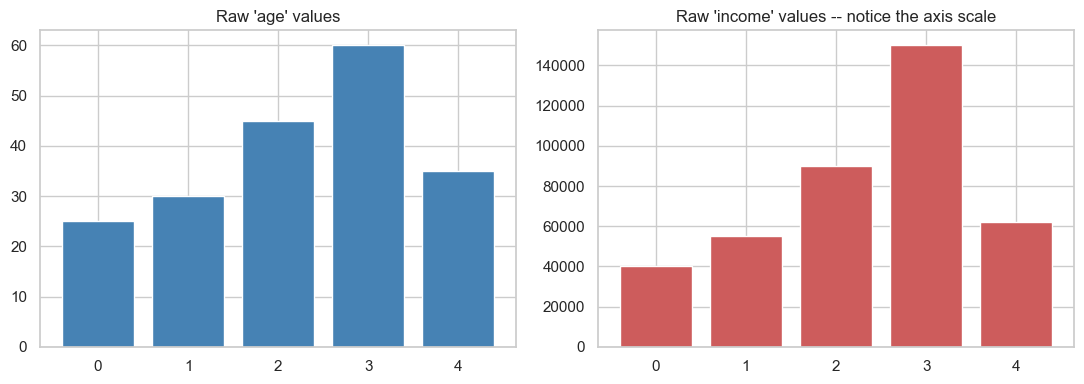

Without scaling, 'income' would dominate any distance or gradient calculation --
not because it's more important, but purely because its numbers are bigger.


In [5]:
# A deliberately lopsided pair of features -- age (small numbers) and income (large numbers) --
# to make the scale mismatch obvious.
demo = pd.DataFrame({'age': [25, 30, 45, 60, 35], 'income': [40000, 55000, 90000, 150000, 62000]})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(range(len(demo)), demo['age'], color='steelblue')
axes[0].set_title("Raw 'age' values")
axes[1].bar(range(len(demo)), demo['income'], color='indianred')
axes[1].set_title("Raw 'income' values -- notice the axis scale")
plt.tight_layout()
plt.show()

print("Without scaling, 'income' would dominate any distance or gradient calculation --")
print("not because it's more important, but purely because its numbers are bigger.")

In [6]:
scaled = StandardScaler().fit_transform(demo)
scaled_df = pd.DataFrame(scaled, columns=demo.columns)
print('After StandardScaler -- both columns now centered at 0 with the same spread:')
print(scaled_df.round(2))

After StandardScaler -- both columns now centered at 0 with the same spread:
    age  income
0 -1.13   -1.01
1 -0.73   -0.63
2  0.48    0.27
3  1.69    1.82
4 -0.32   -0.45


**One-line rule of thumb, worth remembering over any formula:** scale numeric features by default
unless you're specifically using a tree-based model (Decision Tree, Random Forest, Gradient
Boosting) -- for those, skip it, it won't help and won't hurt.

### 2.2 -- Fixing a Skewed Distribution

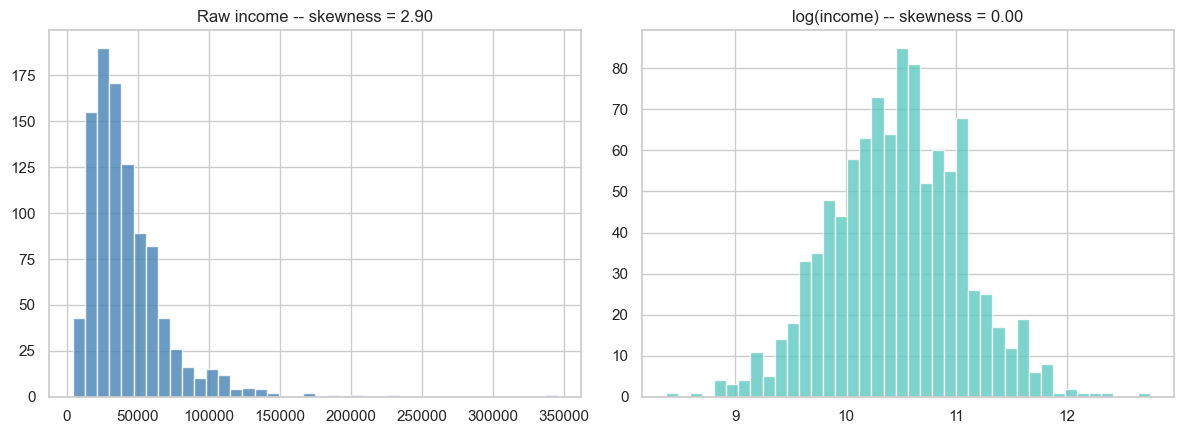

In [7]:
# Simulate a realistic right-skewed column -- most values modest, a long tail of large ones,
# exactly the shape household income, house prices, or transaction amounts usually take.
rng = np.random.default_rng(1)
skewed_income = rng.lognormal(mean=10.5, sigma=0.6, size=1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(skewed_income, bins=40, color='steelblue', alpha=0.8)
axes[0].set_title(f'Raw income -- skewness = {pd.Series(skewed_income).skew():.2f}')

log_income = np.log(skewed_income)
axes[1].hist(log_income, bins=40, color='#5ec8c0', alpha=0.8)
axes[1].set_title(f'log(income) -- skewness = {pd.Series(log_income).skew():.2f}')
plt.tight_layout()
plt.show()

**The intuition behind `log(x)`, without the calculus:** it compresses big numbers much more than
small ones. The gap between \$40,000 and \$50,000 shrinks a little; the gap between \$400,000 and
\$4,000,000 shrinks enormously. That's exactly what a long right tail needs -- pulled in toward the
rest of the data instead of stretching the whole scale to accommodate a handful of extreme values.
`PowerTransformer` finds a similar fix automatically, including for columns with zeros or negative
numbers that plain `log` can't handle.

In [8]:
power = PowerTransformer(method='yeo-johnson')
transformed = power.fit_transform(skewed_income.reshape(-1, 1)).ravel()
print(f'Raw skewness: {pd.Series(skewed_income).skew():.2f}')
print(f'PowerTransformer skewness: {pd.Series(transformed).skew():.2f}')
print('Close to 0 skewness means close to symmetric -- exactly what many models prefer to work with.')

Raw skewness: 2.90
PowerTransformer skewness: -0.00
Close to 0 skewness means close to symmetric -- exactly what many models prefer to work with.


---
## Part 3 -- Binning: Turning a Number Into a Category

**The mental model:** sometimes the exact number matters less than which *range* it falls into.
Age 34 and age 36 behave almost identically for most purposes -- but "under 18" vs. "18 and over"
can flip a rule entirely. Binning trades precision for simplicity or for capturing a threshold
effect a smooth model would otherwise miss.

In [9]:
ages = np.array([5, 12, 17, 22, 34, 45, 58, 67, 74, 81])

binner = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')
bin_labels = binner.fit_transform(ages.reshape(-1, 1)).ravel().astype(int)

for age, label in zip(ages, bin_labels):
    print(f'age {age:>3} -> bin {label}')

print(f'\nBin edges: {np.round(binner.bin_edges_[0], 1)}')

age   5 -> bin 0
age  12 -> bin 0
age  17 -> bin 1
age  22 -> bin 1
age  34 -> bin 1
age  45 -> bin 2
age  58 -> bin 2
age  67 -> bin 3
age  74 -> bin 3
age  81 -> bin 3

Bin edges: [ 5.  17.  39.5 67.  81. ]


**`strategy='quantile'` puts roughly equal numbers of rows in each bin** -- useful when you want
"low / medium / high" to each represent a similar-sized group. `strategy='uniform'` instead gives
every bin the same-width range, regardless of how many rows land in it. Neither is "correct" in
general -- it depends on whether you care about equal group sizes or equal-sized ranges.

**What's genuinely lost:** ages 5 and 12 end up in the same bin above, indistinguishable to the
model afterward, even though a 5-year-old and a 12-year-old can behave very differently. Binning is
a deliberate trade, not a free simplification.

---
## Part 4 -- Categorical Encoding: One-Hot, Ordinal, and Target Encoding

### 4.1 -- One-Hot vs. Ordinal: the Same Test, Every Time

In [15]:
# neighborhood has NO natural order -- one-hot is correct.
neighborhoods = pd.DataFrame({'neighborhood': ['Downtown', 'Suburb', 'Rural', 'Suburb', 'Downtown']})
onehot = OneHotEncoder(sparse_output=False)
print('One-hot (no order implied):')
print(pd.DataFrame(onehot.fit_transform(neighborhoods), columns=onehot.get_feature_names_out()))

# education level DOES have a natural order -- ordinal is correct, and uses only ONE column.
education = pd.DataFrame({'education': ['High School', 'Bachelors', 'Masters', 'Bachelors', 'PhD']})
order = [['High School', 'Bachelors', 'Masters', 'PhD']]
ordinal = OrdinalEncoder(categories=order)
print('\nOrdinal (order preserved, one column):')
result = ordinal.fit_transform(education)
for val, code_num in zip(education['education'], result.ravel()):
    print(f'  {val:<12} -> {code_num:.0f}')

One-hot (no order implied):
   neighborhood_Downtown  neighborhood_Rural  neighborhood_Suburb
0                    1.0                 0.0                  0.0
1                    0.0                 0.0                  1.0
2                    0.0                 1.0                  0.0
3                    0.0                 0.0                  1.0
4                    1.0                 0.0                  0.0

Ordinal (order preserved, one column):
  High School  -> 0
  Bachelors    -> 1
  Masters      -> 2
  Bachelors    -> 1
  PhD          -> 3


In [18]:
onehot = OneHotEncoder(sparse_output=False)

encoded = onehot.fit_transform(neighborhoods)

print(encoded)

[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [19]:
onehot = OneHotEncoder()
result = onehot.fit_transform(neighborhoods)

print(result)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (5, 3)>
  Coords	Values
  (0, 0)	1.0
  (1, 2)	1.0
  (2, 1)	1.0
  (3, 2)	1.0
  (4, 0)	1.0


**The test to apply every time, worth repeating:** would it make sense to say one category is
"between" two others? For `education`, yes -- Bachelors sits between High School and Masters. For
`neighborhood`, no -- there's no meaningful sense in which Suburb is "between" Downtown and Rural.
Using ordinal encoding on the wrong kind of column invents a fake distance the model will
mistakenly try to learn from.

### 4.2 -- High Cardinality: When One-Hot Gets Unwieldy

In [20]:
rng = np.random.default_rng(5)
n = 2000
zip_code = rng.choice([f'ZIP-{i:03d}' for i in range(80)], n)   # 80 distinct zip codes
print(f'{zip_code.__class__.__name__} with {len(np.unique(zip_code))} distinct values')
print(f'One-hot encoding this column alone would create {len(np.unique(zip_code))} new columns.')

ndarray with 80 distinct values
One-hot encoding this column alone would create 80 new columns.


**Target encoding's mental model:** instead of one column per zip code, replace each zip code with
a single number -- the average of the target (say, house price) for rows sharing that zip code.
"ZIP-014's houses average \$410,000" becomes one informative number, not 80 mostly-empty columns.

There's no ready-made scikit-learn transformer for this, so building one is a genuinely useful
exercise -- and it makes the leakage risk in Part 8 much easier to see, because you'll have written
the exact line of code that can leak.

In [21]:
class SimpleTargetEncoder(BaseEstimator, TransformerMixin):
    # Replaces each category with the mean target value for that category, learned from
    # whatever data .fit() is called on. Unseen categories at transform time fall back to the
    # overall mean seen during fit -- never to anything computed from the new data itself.

    def __init__(self, column):
        self.column = column

    def fit(self, X, y):
        df = pd.DataFrame({self.column: X[self.column], 'target': y})
        self.category_means_ = df.groupby(self.column)['target'].mean()
        self.global_mean_ = y.mean()
        return self

    def transform(self, X):
        encoded = X[self.column].map(self.category_means_).fillna(self.global_mean_)
        return encoded.to_frame(name=f'{self.column}_target_encoded')

In [22]:
demo_df = pd.DataFrame({'zip_code': zip_code})
demo_price = 200000 + rng.normal(0, 30000, n) + (pd.Series(zip_code).str[4:].astype(int) * 800)

encoder = SimpleTargetEncoder(column='zip_code')
encoder.fit(demo_df, demo_price)
encoded = encoder.transform(demo_df)

print('A few learned zip-code averages:')
print(encoder.category_means_.head())
print(f'\n80 zip codes collapsed into 1 informative numeric column, instead of 80 one-hot columns.')

A few learned zip-code averages:
zip_code
ZIP-000    199227.793008
ZIP-001    200351.083608
ZIP-002    197333.594252
ZIP-003    203455.017034
ZIP-004    213146.304222
Name: target, dtype: float64

80 zip codes collapsed into 1 informative numeric column, instead of 80 one-hot columns.


---
## Part 5 -- Date and Time Features

In [23]:
dates = pd.to_datetime(['2024-01-15', '2024-03-22', '2024-07-04', '2024-11-28', '2024-12-31'])
date_df = pd.DataFrame({'date': dates})

# .dt gives instant access to every calendar field hiding inside a raw timestamp.
date_df['month'] = date_df['date'].dt.month
date_df['day_of_week'] = date_df['date'].dt.day_name()
date_df['is_weekend'] = date_df['date'].dt.dayofweek >= 5
date_df['day_of_year'] = date_df['date'].dt.dayofyear
print(date_df)

        date  month day_of_week  is_weekend  day_of_year
0 2024-01-15      1      Monday       False           15
1 2024-03-22      3      Friday       False           82
2 2024-07-04      7    Thursday       False          186
3 2024-11-28     11    Thursday       False          333
4 2024-12-31     12     Tuesday       False          366


### 5.2 -- The Cyclical Encoding Trap

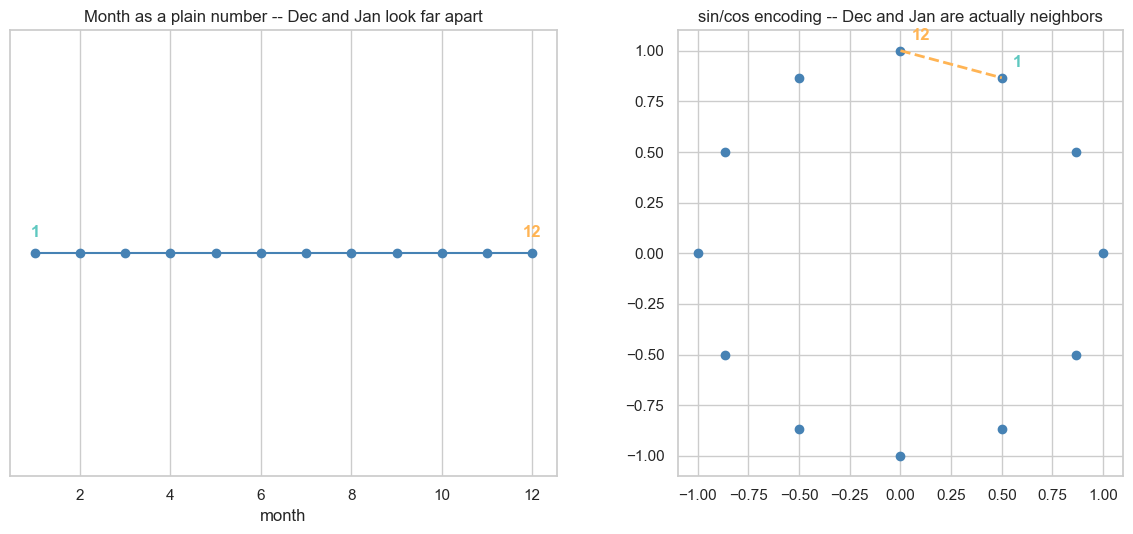

In [24]:
months = np.arange(1, 13)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# Plain month number on a line -- December (12) and January (1) look maximally FAR apart.
axes[0].plot(months, np.zeros(12), 'o-', color='steelblue')
for m in [1, 12]:
    axes[0].annotate(str(m), (m, 0), textcoords='offset points', xytext=(0, 12), ha='center',
                      color='#ffb454' if m == 12 else '#5ec8c0', fontweight='bold')
axes[0].set_yticks([])
axes[0].set_title('Month as a plain number -- Dec and Jan look far apart')
axes[0].set_xlabel('month')

# sin/cos encoding places every month on a circle -- December and January end up genuinely close.
angles = 2 * np.pi * months / 12
x_coords, y_coords = np.sin(angles), np.cos(angles)
axes[1].plot(x_coords, y_coords, 'o', color='steelblue')
axes[1].plot([x_coords[-1], x_coords[0]], [y_coords[-1], y_coords[0]], '--', color='#ffb454', linewidth=2)
for m in [1, 12]:
    axes[1].annotate(str(m), (x_coords[m-1], y_coords[m-1]), textcoords='offset points',
                      xytext=(8, 8), color='#ffb454' if m == 12 else '#5ec8c0', fontweight='bold')
axes[1].set_aspect('equal')
axes[1].set_title('sin/cos encoding -- Dec and Jan are actually neighbors')

plt.tight_layout()
plt.show()

In [25]:
# The two new columns, computed directly -- no library needed, just the formula from the slides.
date_df['month_sin'] = np.sin(2 * np.pi * date_df['month'] / 12)
date_df['month_cos'] = np.cos(2 * np.pi * date_df['month'] / 12)
print(date_df[['date', 'month', 'month_sin', 'month_cos']])

        date  month     month_sin     month_cos
0 2024-01-15      1  5.000000e-01  8.660254e-01
1 2024-03-22      3  1.000000e+00  6.123234e-17
2 2024-07-04      7 -5.000000e-01 -8.660254e-01
3 2024-11-28     11 -5.000000e-01  8.660254e-01
4 2024-12-31     12 -2.449294e-16  1.000000e+00


**Why two columns and not one:** a single sine wave alone can't distinguish month 3 from month 9 --
both give the same sine value on parts of the cycle. Pairing sine with cosine (think of it as an
x-coordinate and a y-coordinate on a circle) gives every month a unique, unambiguous position, with
neighboring months always close together, wherever they fall on the calendar.

---
## Part 6 -- Interaction Features: When Two Columns Say More Together

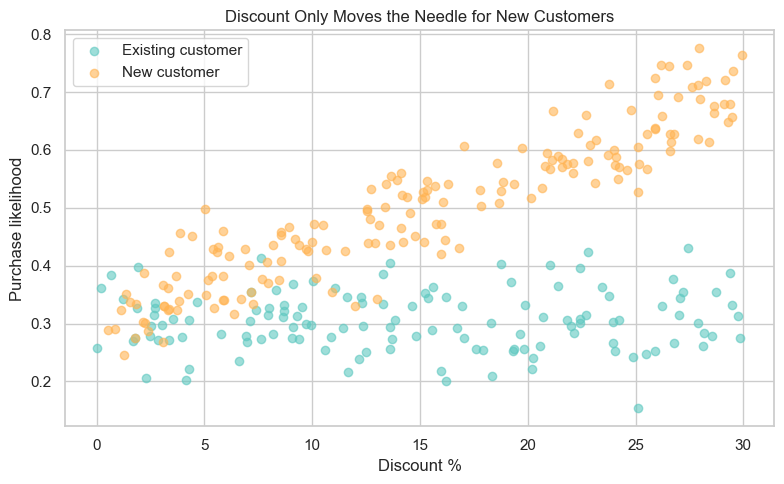

In [26]:
# A relationship that ONLY shows up in combination: a discount matters a lot for new customers,
# and barely at all for loyal ones -- neither column alone captures this.
rng = np.random.default_rng(9)
n = 300
is_new_customer = rng.choice([0, 1], n)
discount_pct = rng.uniform(0, 30, n)

# purchase_likelihood depends on the INTERACTION, not on either feature alone.
purchase_likelihood = 0.3 + 0.4 * is_new_customer * (discount_pct / 30) + rng.normal(0, 0.05, n)
purchase_likelihood = np.clip(purchase_likelihood, 0, 1)

fig, ax = plt.subplots(figsize=(8, 5))
for label, color in [(0, '#5ec8c0'), (1, '#ffb454')]:
    mask = is_new_customer == label
    ax.scatter(discount_pct[mask], purchase_likelihood[mask], alpha=0.6, color=color,
               label='New customer' if label else 'Existing customer')
ax.set_xlabel('Discount %')
ax.set_ylabel('Purchase likelihood')
ax.set_title('Discount Only Moves the Needle for New Customers')
ax.legend()
plt.tight_layout()
plt.show()

**Two separate upward slopes, not one.** A model given only `is_new_customer` and `discount_pct`
as independent features has to describe each one's *average* effect across everybody -- it can't
represent "discount matters a lot here, barely at all there" without an explicit interaction
column doing that multiplication for it.

In [28]:
interaction_df = pd.DataFrame({'is_new_customer': is_new_customer, 'discount_pct': discount_pct})
interaction_df['new_x_discount'] = interaction_df['is_new_customer'] * interaction_df['discount_pct']
print(interaction_df.head())

# PolynomialFeatures(interaction_only=True) generates every pairwise product automatically --
# useful for a first pass across many columns, though it grows fast, same caution as Lecture 02.
poly = PolynomialFeatures(interaction_only=True, include_bias=False)
generated = poly.fit_transform(interaction_df[['is_new_customer', 'discount_pct']])
print(f'\nPolynomialFeatures generated columns: {poly.get_feature_names_out()}')

   is_new_customer  discount_pct  new_x_discount
0                0     17.030535        0.000000
1                1      3.749936        3.749936
2                1     12.669476       12.669476
3                0     19.621678        0.000000
4                0     12.303365        0.000000

PolynomialFeatures generated columns: ['is_new_customer' 'discount_pct' 'is_new_customer discount_pct']


---
## Part 7 -- Aggregation Features: Comparing a Row to Its Group

In [29]:
rng = np.random.default_rng(11)
n = 400
area_sqft = rng.normal(1800, 550, n).clip(450, 4200)
neighborhood = rng.choice(['Downtown', 'Suburb', 'Rural'], n, p=[0.3, 0.5, 0.2])
neighborhood_premium = np.select([neighborhood == 'Downtown', neighborhood == 'Suburb'], [45000, 15000], default=0)
price = (120 * area_sqft + neighborhood_premium + 20000 + rng.normal(0, 25000, n)).clip(40000, None)

houses = pd.DataFrame({'area_sqft': area_sqft, 'neighborhood': neighborhood, 'price': price})

# groupby().transform() computes each row's GROUP average, but returns it aligned back to every
# row -- not collapsed into a smaller summary table. Exactly what's needed for a new feature column.
houses['neighborhood_avg_price'] = houses.groupby('neighborhood')['price'].transform('mean')
houses['price_vs_neighborhood'] = houses['price'] / houses['neighborhood_avg_price']

print(houses.head(8))

     area_sqft neighborhood          price  neighborhood_avg_price  \
0  1818.806022        Rural  218039.276180           236024.717681   
1  2547.861147     Downtown  370034.027342           283945.791908   
2  2473.596593       Suburb  361936.378559           256884.864776   
3  1519.331108       Suburb  182580.973634           256884.864776   
4  1636.116769        Rural  206738.967753           236024.717681   
5  1509.938694        Rural  166605.752762           236024.717681   
6  2113.349497     Downtown  372905.827033           283945.791908   
7  1769.164559       Suburb  292757.735382           256884.864776   

   price_vs_neighborhood  
0               0.923798  
1               1.303185  
2               1.408944  
3               0.710750  
4               0.875921  
5               0.705883  
6               1.313299  
7               1.139646  


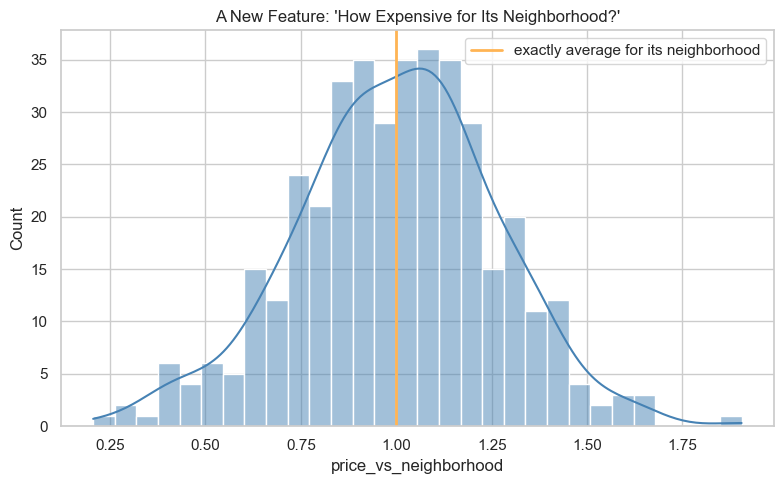

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(houses['price_vs_neighborhood'], bins=30, kde=True, color='steelblue', ax=ax)
ax.axvline(1.0, color='#ffb454', linewidth=2, label='exactly average for its neighborhood')
ax.set_title("A New Feature: 'How Expensive for Its Neighborhood?'")
ax.legend()
plt.tight_layout()
plt.show()

**The mental model:** `price_vs_neighborhood` above 1.0 means "pricier than a typical house in the
same neighborhood," below 1.0 means "cheaper than typical there." This relative view can carry
signal that raw `price` alone can't -- a \$500,000 house is unremarkable Downtown but striking in a
Rural neighborhood, and this feature captures that directly instead of leaving a model to infer it
from `price` and `neighborhood` separately.

---
## Part 8 -- The Leakage Trap for Feature Engineering, Demonstrated

Target encoding and aggregation features are especially easy to leak, because the feature itself
is built from the target (or from other rows). Same instinct as the pure-noise demonstrations in
Lectures 03 and 04 -- prove the point with numbers, not just a warning.

In [31]:
# A high-cardinality category with NO real relationship to the target -- any performance a model
# appears to gain from encoding it should be zero, honestly measured.
rng = np.random.default_rng(21)
n = 300
random_category = rng.choice([f'CAT-{i}' for i in range(60)], n)   # 60 categories, purely random
y_noise = rng.normal(0, 1, n)   # target with NO real relationship to random_category

df_noise = pd.DataFrame({'category': random_category})

In [32]:
# THE LEAKY WAY: fit the target encoder on ALL the data -- including rows that will later become
# the test set -- so each row's own target value has already leaked into its encoded feature.
X_train, X_test, y_train, y_test = train_test_split(df_noise, y_noise, test_size=0.3, random_state=0)

leaky_encoder = SimpleTargetEncoder(column='category')
leaky_encoder.fit(df_noise, y_noise)          # fit on EVERYTHING, before the split even matters
X_train_leaky = leaky_encoder.transform(X_train)
X_test_leaky = leaky_encoder.transform(X_test)

model_leaky = LinearRegression().fit(X_train_leaky, y_train)
leaky_r2 = model_leaky.score(X_test_leaky, y_test)
print(f'LEAKY approach -- test R²: {leaky_r2:.3f}')

LEAKY approach -- test R²: 0.174


In [33]:
# THE CORRECT WAY: fit the target encoder on the TRAINING split only, then apply it to the test
# split -- the test rows' own target values never influence their encoded feature.
correct_encoder = SimpleTargetEncoder(column='category')
correct_encoder.fit(X_train, y_train)          # fit on TRAINING data only
X_train_correct = correct_encoder.transform(X_train)
X_test_correct = correct_encoder.transform(X_test)

model_correct = LinearRegression().fit(X_train_correct, y_train)
correct_r2 = model_correct.score(X_test_correct, y_test)
print(f'CORRECT approach -- test R²: {correct_r2:.3f}')

CORRECT approach -- test R²: -0.416


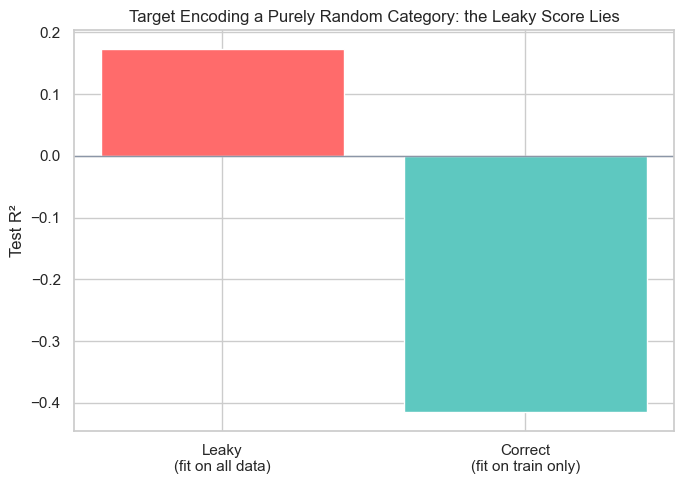

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['Leaky\n(fit on all data)', 'Correct\n(fit on train only)'],
       [leaky_r2, correct_r2], color=['#ff6b6b', '#5ec8c0'])
ax.axhline(0, color='#8b96a7', linewidth=1)
ax.set_ylabel('Test R²')
ax.set_title('Target Encoding a Purely Random Category: the Leaky Score Lies')
plt.tight_layout()
plt.show()

**`random_category` has zero real relationship to `y_noise` -- the honest R² for any method here
is 0.** The leaky approach reports a misleadingly positive R², because each row's encoded value was
partly computed *from that row's own target* before the split ever happened -- with 60 categories
and only ~210 training rows, many categories have just a handful of rows, so their "average" is
practically memorizing individual target values. The correct approach, fitting only on the training
split, reports a score close to zero -- the honest answer. **This is exactly why a target encoder
belongs inside a `Pipeline`** (or, at minimum, is always fit after the split, never before it) --
identical to the rule from Lectures 03 and 04, now applied to a technique that's easy to get wrong
precisely because it looks like ordinary feature engineering rather than an obvious shortcut.

---
## Part 9 -- Outliers: Detect Mechanically, Decide With Judgment

In [35]:
rng = np.random.default_rng(13)
salaries = np.concatenate([rng.normal(65000, 12000, 195), [280000, 310000, 5000, 295000, 8000]])

Q1, Q3 = np.percentile(salaries, [25, 75])
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
is_outlier_iqr = (salaries < lower_bound) | (salaries > upper_bound)

z_scores = (salaries - salaries.mean()) / salaries.std()
is_outlier_z = np.abs(z_scores) > 3

print(f'IQR method flagged: {is_outlier_iqr.sum()} points  (bounds: {lower_bound:,.0f} to {upper_bound:,.0f})')
print(f'Z-score method flagged: {is_outlier_z.sum()} points  (|z| > 3)')

IQR method flagged: 7 points  (bounds: 33,509 to 100,267)
Z-score method flagged: 3 points  (|z| > 3)


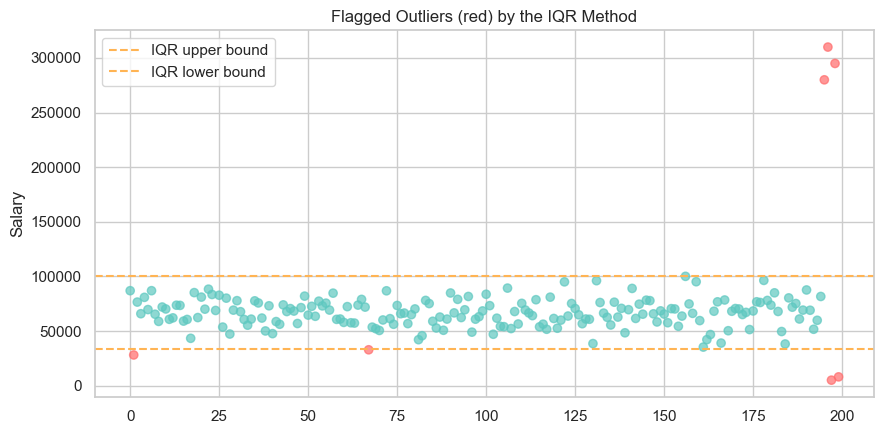

In [36]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(range(len(salaries)), salaries, c=np.where(is_outlier_iqr, '#ff6b6b', '#5ec8c0'), alpha=0.7)
ax.axhline(upper_bound, color='#ffb454', linestyle='--', label='IQR upper bound')
ax.axhline(lower_bound, color='#ffb454', linestyle='--', label='IQR lower bound')
ax.set_ylabel('Salary')
ax.set_title('Flagged Outliers (red) by the IQR Method')
ax.legend()
plt.tight_layout()
plt.show()

**Detection is the easy, mechanical part -- deciding what to do next is judgment, not math.** A
\$5,000 salary might be a data-entry error (missing a digit); a genuine \$310,000 salary might be a
real senior executive who matters a great deal to a compensation model. The same detection rule
flags both -- only domain knowledge can tell them apart.

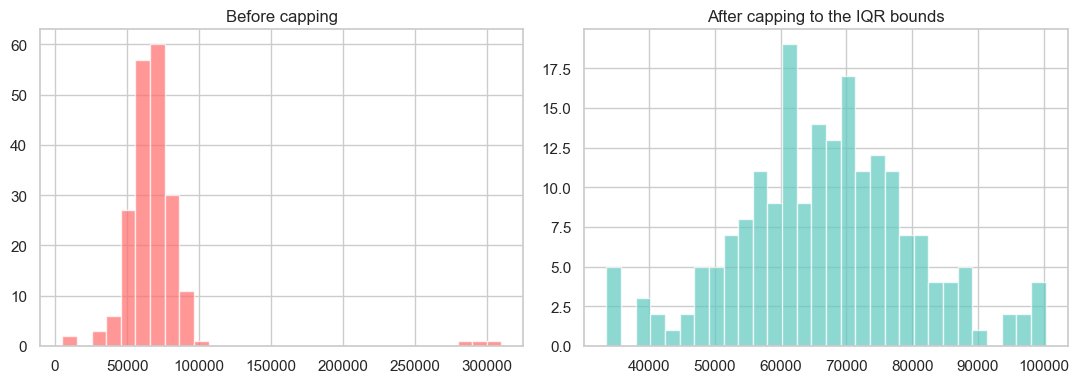

In [37]:
# Capping (winsorizing): keep every row, but pull extreme values in to a reasonable boundary --
# softens their influence without discarding the row entirely.
salaries_capped = np.clip(salaries, lower_bound, upper_bound)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(salaries, bins=30, color='#ff6b6b', alpha=0.7)
axes[0].set_title('Before capping')
axes[1].hist(salaries_capped, bins=30, color='#5ec8c0', alpha=0.7)
axes[1].set_title('After capping to the IQR bounds')
plt.tight_layout()
plt.show()

---
## Part 10 -- Putting It All Together: One Honest Pipeline

Every technique from this notebook, combined on one dataset, with the leakage rule (Lecture 04's
rule, applying here too) built in by construction rather than remembered by hand.

In [38]:
rng = np.random.default_rng(7)
n = 600
area_sqft = rng.normal(1800, 550, n).clip(450, 4200)
bedrooms = np.round(area_sqft / 650 + rng.normal(0, 0.6, n)).clip(1, 6).astype(int)
age_years = rng.uniform(0, 60, n)
neighborhood = rng.choice(['Downtown', 'Suburb', 'Rural'], n, p=[0.3, 0.5, 0.2])
zip_code = rng.choice([f'ZIP-{i:03d}' for i in range(40)], n)
sale_month = rng.integers(1, 13, n)
neighborhood_premium = np.select([neighborhood == 'Downtown', neighborhood == 'Suburb'], [45000, 15000], default=0)
price = (120*area_sqft + 8000*bedrooms - 900*age_years + neighborhood_premium + 20000
          + rng.normal(0, 25000, n)).clip(40000, None)

housing = pd.DataFrame({'area_sqft': area_sqft, 'bedrooms': bedrooms, 'age_years': age_years,
                         'neighborhood': neighborhood, 'zip_code': zip_code, 'sale_month': sale_month,
                         'price': price})

# Engineer cyclical month features and an interaction term BEFORE the ColumnTransformer, since
# they're simple deterministic formulas -- not statistics learned from the target, so no leakage
# risk from computing them before the split (unlike the target-encoded zip_code below).
housing['month_sin'] = np.sin(2 * np.pi * housing['sale_month'] / 12)
housing['month_cos'] = np.cos(2 * np.pi * housing['sale_month'] / 12)
housing['area_x_bedrooms'] = housing['area_sqft'] * housing['bedrooms']

feature_cols = ['area_sqft', 'bedrooms', 'age_years', 'neighborhood', 'zip_code',
                 'month_sin', 'month_cos', 'area_x_bedrooms']
X = housing[feature_cols]
y = housing['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (480, 8), Test: (120, 8)


In [39]:
class TargetEncoderStep(BaseEstimator, TransformerMixin):
    # A Pipeline-compatible wrapper around SimpleTargetEncoder, so it gets refit on training
    # data only every time this Pipeline is fit -- inside cross-validation, inside a grid search,
    # or on the final train/test split, always automatically.

    def __init__(self, column):
        self.column = column

    def fit(self, X, y):
        self.encoder_ = SimpleTargetEncoder(column=self.column).fit(X, y)
        return self

    def transform(self, X):
        return self.encoder_.transform(X)

preprocessor = ColumnTransformer([
    ('scale_numeric', StandardScaler(), ['area_sqft', 'bedrooms', 'age_years', 'month_sin',
                                           'month_cos', 'area_x_bedrooms']),
    ('onehot_neighborhood', OneHotEncoder(drop='first'), ['neighborhood']),
    ('target_encode_zip', TargetEncoderStep(column='zip_code'), ['zip_code']),
])

full_pipeline = Pipeline([('preprocess', preprocessor), ('model', LinearRegression())])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
engineered_scores = cross_val_score(full_pipeline, X_train, y_train, cv=cv, scoring='r2')
print(f'Engineered features -- CV R²: {engineered_scores.mean():.3f} ± {engineered_scores.std():.3f}')

Engineered features -- CV R²: 0.878 ± 0.019


In [40]:
# A baseline for comparison: only the raw numeric/categorical columns, none of today's engineered
# features (no cyclical month, no interaction term, no target-encoded zip code).
baseline_preprocessor = ColumnTransformer([
    ('scale_numeric', StandardScaler(), ['area_sqft', 'bedrooms', 'age_years']),
    ('onehot_neighborhood', OneHotEncoder(drop='first'), ['neighborhood']),
])
baseline_pipeline = Pipeline([('preprocess', baseline_preprocessor), ('model', LinearRegression())])

baseline_scores = cross_val_score(baseline_pipeline,
                                    X_train[['area_sqft', 'bedrooms', 'age_years', 'neighborhood']],
                                    y_train, cv=cv, scoring='r2')
print(f'Baseline (no engineered features) -- CV R²: {baseline_scores.mean():.3f} ± {baseline_scores.std():.3f}')
print(f'Engineered features             -- CV R²: {engineered_scores.mean():.3f} ± {engineered_scores.std():.3f}')

Baseline (no engineered features) -- CV R²: 0.882 ± 0.019
Engineered features             -- CV R²: 0.878 ± 0.019


**Worth being honest about this result: the engineered features didn't beat the baseline here** --
the two scores are statistically indistinguishable (both around 0.88, well within each other's
standard deviation). That's not a failure of the notebook, it's the correct outcome given how this
dataset was built: `price` was generated from `area_sqft`, `bedrooms`, `age_years`, and
`neighborhood` alone -- `zip_code`, `sale_month`, and the interaction term carry essentially no
real relationship to price by construction, so a good encoding of them should neither help nor
hurt much. **This is exactly the value of checking with cross-validation instead of assuming a new
feature helped just because it was thoughtfully engineered** -- on a real dataset, where you don't
know the true generating process in advance, this comparison is how you'd actually find out.

In [41]:
full_pipeline.fit(X_train, y_train)
test_r2 = full_pipeline.score(X_test, y_test)
test_mae = mean_absolute_error(y_test, full_pipeline.predict(X_test))
print(f'Final model, evaluated ONCE on the held-out test set:')
print(f'  Test R²: {test_r2:.3f}')
print(f'  Test MAE: ${test_mae:,.0f}')

Final model, evaluated ONCE on the held-out test set:
  Test R²: 0.915
  Test MAE: $17,676


**Every engineered feature in this pipeline was built the safe way:** the cyclical month features
and the interaction term are pure formulas with no dependence on the target, so they're safe to
compute anywhere; the target-encoded `zip_code` is wrapped in a `Pipeline` step, so cross-validation
and the final fit both refit it on training data only, automatically. Nothing here depended on
remembering the leakage rule by hand -- the pipeline's structure enforces it.

---
## Summary

| Part | Technique | Key operation |
|---|---|---|
| **Missing values** | Impute thoughtfully | `SimpleImputer(strategy=...)`, `add_indicator=True` for a "was missing" flag |
| **Scaling** | Matters for linear/distance models | `StandardScaler()` -- skip for tree-based models |
| **Skew** | Reshape lopsided distributions | `np.log(x)` or `PowerTransformer()` |
| **Binning** | Number to category | `KBinsDiscretizer(n_bins=, strategy=)` -- trades precision for simplicity |
| **Encoding** | Match the encoder to the category type | `OneHotEncoder` (unordered), `OrdinalEncoder` (ordered), target encoding (high cardinality) |
| **Dates** | Extract calendar signal | `.dt.month`, `.dt.dayofweek`, etc. |
| **Cyclical features** | Fix the "Dec/Jan are far apart" bug | `sin(2*pi*x/period)` + `cos(2*pi*x/period)`, always as a pair |
| **Interactions** | Capture combined effects | Manual multiplication, or `PolynomialFeatures(interaction_only=True)` |
| **Aggregations** | Compare a row to its group | `groupby(...).transform('mean')` |
| **The leakage trap** | Fit on training data only | Wrap data-dependent encoders in a custom `Pipeline`-compatible transformer |
| **Outliers** | Detect mechanically, decide with judgment | IQR or z-score to flag; cap, remove, or keep based on domain knowledge |

---

**Next lecture:** Classification turns to predicting a category instead of a number -- every
technique from today (encoding, scaling, engineered features, the leakage rule) carries over
directly onto a new kind of target.